In [16]:
import numpy as np
import matplotlib.pyplot as plt

from theoretical import *
from control_functional_implementation import *

In [3]:
def f_in_RKHS(kernel_fn, loc, scale, length_scale=1.0, decay_scale=5e-3):
    def f(x):
        K = kernel_fn(x, loc, length_scale=length_scale, decay_scale=decay_scale)
        return K @ scale
    return f

In [4]:
# Representative 1
loc1 = np.array([-3.0, 1.2, 2.5]).reshape(3, 1)
scale1 = np.array([1.5, -0.5, 1.25]).reshape(3, 1)

f1_mod_rbf = f_in_RKHS(modified_rbf_kernel, loc1, scale1, length_scale=1.0)
f1_stein = f_in_RKHS(modified_stein_rbf_kernel, loc1, scale1, length_scale=1.0)

# Representative 2
loc2 = np.array([-2.0, 2.0]).reshape(2, 1)
scale2 = np.array([-0.7, 0.75]).reshape(2, 1)

f2_mod_rbf = f_in_RKHS(modified_rbf_kernel, loc2, scale2, length_scale=1.0)
f2_stein = f_in_RKHS(modified_stein_rbf_kernel, loc2, scale2, length_scale=1.0)

# Representative 3
loc3 = np.array([0.4]).reshape(1, 1)
scale3 = np.array([0.5]).reshape(1, 1)

f3_mod_rbf = f_in_RKHS(modified_rbf_kernel, loc3, scale3, length_scale=1.0)
f3_stein = f_in_RKHS(modified_stein_rbf_kernel, loc3, scale3, length_scale=1.0)

# plot the functions
x = np.linspace(-5, 5, 100).reshape(-1, 1)


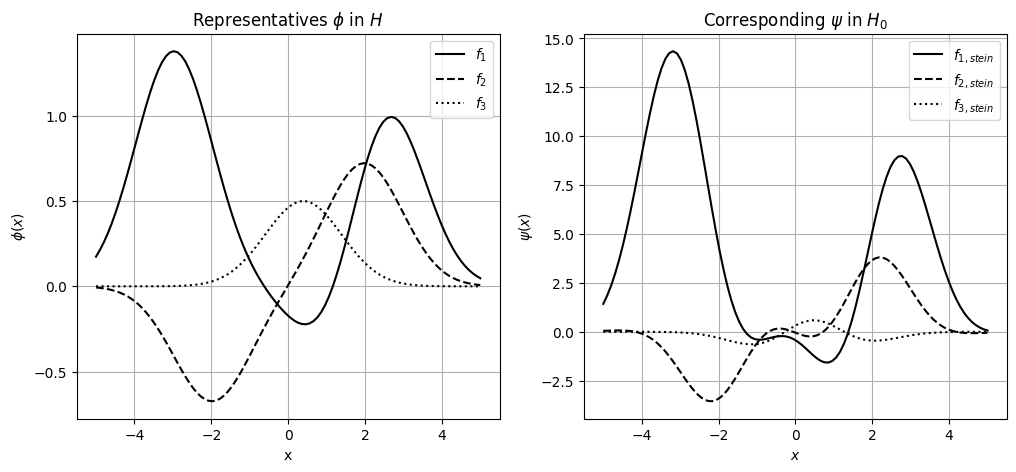

In [10]:
# left plot is f_rbf, right plot is f_stein
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, f1_mod_rbf(x), label="$f_{1}$", color="black")
plt.plot(x, f2_mod_rbf(x), label="$f_{2}$", color="black", linestyle="--")
plt.plot(x, f3_mod_rbf(x), label="$f_{3}$", color="black", linestyle=":")

plt.xlabel("x")
plt.ylabel("$\\phi(x)$")

plt.title("Representatives $\\phi$ in $H$")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, f1_stein(x), label="$f_{1,stein}$", color="black")
plt.plot(x, f2_stein(x), label="$f_{2,stein}$", color="black", linestyle="--")
plt.plot(x, f3_stein(x), label="$f_{3,stein}$", color="black", linestyle=":")

plt.xlabel("$x$")
plt.ylabel("$\\psi(x)$")

plt.title("Corresponding $\\psi$ in $H_{0}$")
plt.grid()
plt.legend()

plt.savefig("../report/assets/RKHS-kernel-functions.png")


In [13]:
# --- Verify mean zero property of Stein functions ---
n = 100_000
np.random.seed(4198)
Z = np.random.normal(size=n).reshape(-1, 1)

# --- RBF functions ---
X1 = f1_mod_rbf(Z)
X2 = f2_mod_rbf(Z)
X3 = f3_mod_rbf(Z)

# --- Stein functions ---
Y1 = f1_stein(Z)
Y2 = f2_stein(Z)
Y3 = f3_stein(Z)

# --- Print means ---
print("Means of phi(Z)")
print(f"{X1.mean():.4f}\t{X2.mean():.4f}\t{X3.mean():.4f}")
print("-----------------------")
print("Means of psi(Z)")
print(f"{Y1.mean():.4f}\t{Y2.mean():.4f}\t{Y3.mean():.4f}")


Means of phi(Z)
0.0383	0.0150	0.3393
-----------------------
Means of psi(Z)
-0.0086	0.0066	0.0017


In [18]:
def butterfly_multistrike(S_0, K1, K2, K3, r, T, sigma):
    """Compute the theoretical price of a butterfly spread option."""
    P1 = european_call(S_0, K1, r, T, sigma)
    P2 = european_call(S_0, K2, r, T, sigma)
    P3 = european_call(S_0, K3, r, T, sigma)
    butterfly_price = P1 - 2 * P2 + P3
    return butterfly_price

def butterfly_option_payoff(S, K1, K2, K3):
    """Compute the payoff of a butterfly spread option."""
    payoff = np.maximum(S - K1, 0) - 2 * np.maximum(S - K2, 0) + np.maximum(S - K3, 0)
    return payoff

def plain_monte_carlo(S_0, K1, K2, K3, r, T, sigma, n):
    """Estimate the price of a butterfly option using plain Monte Carlo."""
    # Simulate end-of-period stock prices
    np.random.seed(4198)
    Z = np.random.normal(size=(n,))
    S_T = S_0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # Compute payoffs
    payoffs = butterfly_option_payoff(S_T, K1, K2, K3)

    # Discounted payoffs
    discounted_payoffs = np.exp(-r * T) * payoffs
    
    # Discounted expected payoff
    est = np.mean(discounted_payoffs)
    std_err = np.std(discounted_payoffs, ddof=1) / np.sqrt(n)
    rel_err = std_err / np.abs(est)

    return est, std_err, rel_err, Z, discounted_payoffs

def control_variate_final_price(S_0, K1, K2, K3, r, T, sigma, n):
    """Estimate the price of a butterfly option using control variates with final stock price."""
    # Simulate end-of-period stock prices
    np.random.seed(4198)
    Z = np.random.normal(size=(n,))
    S_T = S_0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # Compute payoffs
    payoffs = butterfly_option_payoff(S_T, K1, K2, K3)
    
    # Control variate: final stock price
    control_variate = S_T
    
    # Compute covariance and variance
    cov = np.cov(payoffs, control_variate)[0, 1]
    var_control = np.var(control_variate)
    
    # Optimal coefficient
    b_opt = cov / var_control
    
    # Adjusted payoffs
    adjusted_payoffs = payoffs - b_opt * (control_variate - S_0 * np.exp(r * T))

    # Discounted adjusted payoff
    discounted_payoffs = np.exp(-r * T) * adjusted_payoffs
    
    # Discounted expected adjusted payoff
    est = np.mean(discounted_payoffs)
    std_err = np.std(discounted_payoffs, ddof=1) / np.sqrt(n)
    rel_err = std_err / np.abs(est)

    return est, std_err, rel_err, Z, discounted_payoffs

In [19]:
# Setup
np.random.seed(4198)

n = 10_000
S_0, K1, K2, K3 = 50.0, 90.0, 100.0, 120.0   # Deep Out of the Money
r, T, sigma = 0.05, 1.0, 0.3

theoretical_price = butterfly_multistrike(S_0, K1, K2, K3, r, T, sigma)
est_plain, se_plain, re_plain, Z_plain, payoffs_plain = plain_monte_carlo(
    S_0, K1, K2, K3, r, T, sigma, n)
est_cv, se_cv, re_cv, Z_cv, payoffs_cv = control_variate_final_price(
    S_0, K1, K2, K3, r, T, sigma, n)

print(f"Theoretical Price: {theoretical_price:.4f}")
print(f"Plain MC Estimate: {est_plain:.4f}, SE: {se_plain:.4f}, RE: {re_plain:.4%}")
print(f"Control Variate Estimate: {est_cv:.4f}, SE: {se_cv:.4f}, RE: {re_cv:.4%}")

Theoretical Price: 0.0683
Plain MC Estimate: 0.0627, SE: 0.0089, RE: 14.1419%
Control Variate Estimate: 0.0619, SE: 0.0088, RE: 14.1691%


In [20]:
# --- Control Functional Estimator ---
Z_cf = Z_plain.reshape(-1, 1)
Y_cf = payoffs_plain.reshape(-1, 1)

cf_model = ControlFunctional(Z_cf, Y_cf, eta=0.4, length_scale=0.25, decay_scale=1e-3)
cf_model.fit(alpha=1e-3)
cf_model.predict()

y_pred = cf_model.pred

x_train, y_train = cf_model.X_train, cf_model.Y_train
x_test, y_test = cf_model.X_test, cf_model.Y_test

cf_model.summary()

Unbiased Est.: 0.067663
Simplified Est.: 0.069974
SE: 0.001728
RE: 2.5539%


In [21]:
# --- Variance Reduction Factor ---
vrf_plain_cv = re_plain**2 / re_cv**2
print(f"VRF (CV): {vrf_plain_cv:.2f}")

vrf_plain_cf = re_plain**2 / cf_model.re_err**2
print(f"VRF (CF): {vrf_plain_cf:.2f}")

VRF (CV): 1.00
VRF (CF): 30.66


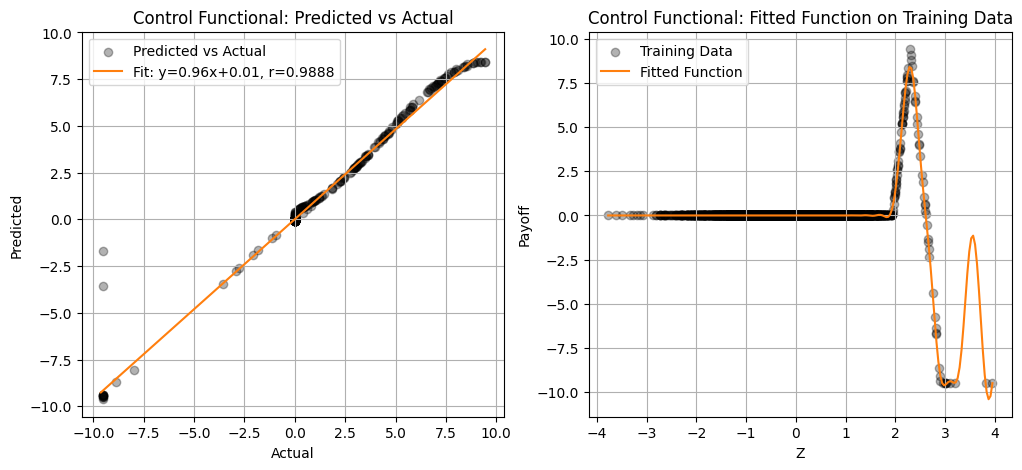

In [22]:
plt.figure(figsize=(12, 5))

# plot y_test vs. y_pred
plt.subplot(1, 2, 1)
plt.scatter(cf_model.Y_test, y_pred, color='black', alpha=0.3, label="Predicted vs Actual")

# plot y_pred ~ y_test line and find the correlation coefficient
min_val = min(np.min(cf_model.Y_test), np.min(y_pred))
max_val = max(np.max(cf_model.Y_test), np.max(y_pred))

slope, intercept = np.polyfit(cf_model.Y_test.flatten(), y_pred.flatten(), 1)
corr = np.corrcoef(cf_model.Y_test.flatten(), y_pred.flatten())[0, 1]

plt.plot([min_val, max_val], [slope * min_val + intercept, slope * max_val + intercept], color='tab:orange', label=f"Fit: y={slope:.2f}x+{intercept:.2f}, r={corr:.4f}")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Control Functional: Predicted vs Actual")

plt.legend()
plt.grid()

# plot x_train vs. y_train + fitted function
plt.subplot(1, 2, 2)

plt.scatter(x_train, y_train, color='black', alpha=0.3, label="Training Data")

xx = np.linspace(np.min(Z_cf), np.max(Z_cf), 200).reshape(-1, 1)
K_xx = modified_stein_rbf_kernel(xx, x_train, length_scale=0.25, decay_scale=1e-3)
ones = np.ones((xx.shape[0], 1))
fitted_values = K_xx @ cf_model.coeffs + (ones - K_xx @ cf_model.const_fn_proj) * cf_model.simplified_estimator

plt.plot(xx, fitted_values, color='tab:orange', label="Fitted Function")
plt.xlabel("Z")
plt.ylabel("Payoff")
plt.title("Control Functional: Fitted Function on Training Data")

plt.legend()
plt.grid()

plt.savefig("../report/assets/butterfly-strike-control-functionals-example.png")

In [23]:
# Helper Functions
def straddle_option_payoff(S_T, K1, K2):
    return np.maximum(S_T - K1, 0) + np.maximum(K2 - S_T, 0)

def final_stock_price(S_0, r, sig, T, Z):
    return S_0 * np.exp((r - 0.5 * sig**2) * T + sig * np.sqrt(T) * Z)

In [24]:
# Straddle Option
np.random.seed(4198)
    
S_0, K, r, T, sig = 50, 50, 0.02, 1.0, 0.2
N = 10_000

Z = np.random.normal(0, 1, N)
S_T = final_stock_price(S_0, r, sig, T, Z)

X = straddle_option_payoff(S_T, K, K) * np.exp(-r * T)

In [25]:
# Control Functional Estimator
X_cf = Z.reshape(-1, 1)
Y_cf = X.reshape(-1, 1)

cf_model = ControlFunctional(X_cf, Y_cf, eta=0.4, length_scale=0.25, decay_scale=1e-3)
cf_model.fit(alpha=1e-3)
cf_model.predict()

y_pred = cf_model.pred

x_train, y_train = cf_model.X_train, cf_model.Y_train
x_test, y_test = cf_model.X_test, cf_model.Y_test

cf_model.summary()

Unbiased Est.: 7.924514
Simplified Est.: 7.913996
SE: 0.007575
RE: 0.0956%


In [26]:
# Straddle Option: Theoretical Price
theoretical_price = straddle_option(S_0, K, r, T, sig)
print(f"Theoretical Price: {theoretical_price:.4f}")

Theoretical Price: 7.9260


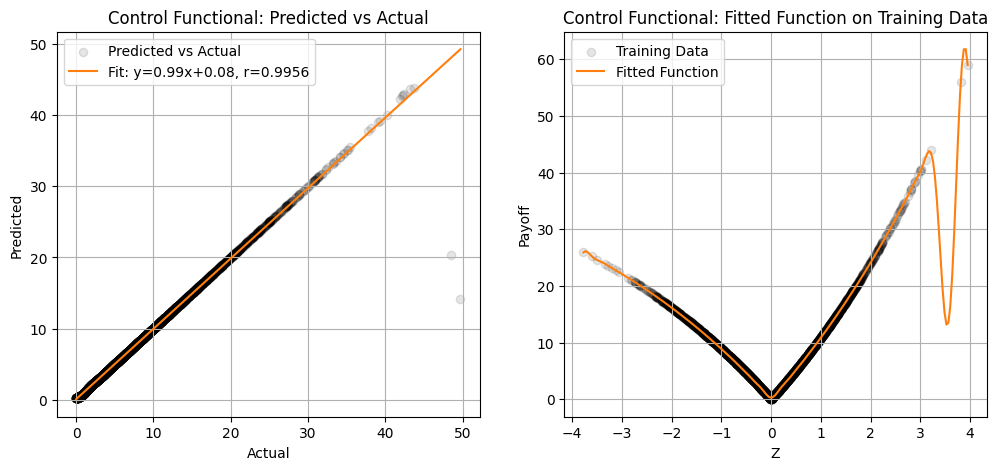

In [27]:
plt.figure(figsize=(12, 5))

# plot y_test vs. y_pred
plt.subplot(1, 2, 1)
plt.scatter(cf_model.Y_test, y_pred, color='black', alpha=0.1, label="Predicted vs Actual")

# plot y_pred ~ y_test line and find the correlation coefficient
min_val = min(np.min(y_test), np.min(y_pred))
max_val = max(np.max(y_test), np.max(y_pred))

slope, intercept = np.polyfit(y_test.flatten(), y_pred.flatten(), 1)
corr = np.corrcoef(y_test.flatten(), y_pred.flatten())[0, 1]

plt.plot([min_val, max_val], [slope * min_val + intercept, slope * max_val + intercept], color='tab:orange', label=f"Fit: y={slope:.2f}x+{intercept:.2f}, r={corr:.4f}")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Control Functional: Predicted vs Actual")

plt.legend()
plt.grid()

# plot x_train vs. y_train + fitted function
plt.subplot(1, 2, 2)

plt.scatter(x_train, y_train, color='black', alpha=0.1, label="Training Data")

xx = np.linspace(np.min(x_train), np.max(x_train), 200).reshape(-1, 1)
K_xx = modified_stein_rbf_kernel(xx, x_train, length_scale=0.25, decay_scale=1e-3)
ones = np.ones((xx.shape[0], 1))
fitted_values = K_xx @ cf_model.coeffs + (ones - K_xx @ cf_model.const_fn_proj) * cf_model.simplified_estimator

plt.plot(xx, fitted_values, color='tab:orange', label="Fitted Function")
plt.xlabel("Z")
plt.ylabel("Payoff")
plt.title("Control Functional: Fitted Function on Training Data")

plt.legend()
plt.grid()

plt.savefig("../report/assets/straddle-option-control-functionals-example.png")